In [1]:
# If needed, install any libraries (commented out here):
# !pip install --quiet torchvision

import os
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Display plots inline
%matplotlib inline

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)


PyTorch version: 2.5.1+cu121
Torchvision version: 0.20.1+cu121


In [2]:

train_dir = "/kaggle/input/image-processing/train-20230326T152931Z-001/train"
val_dir   = "/kaggle/input/image-processing/val-20230326T152503Z-001/val"
test_dir  = "/kaggle/input/image-processing/test-20230326T155708Z-001/test"



In [3]:
# Define data augmentation transforms for training
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),                     # Resize to a larger size
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), # Random crop to 224x224 with random scaling
    transforms.RandomHorizontalFlip(),                 # Random horizontal flip
    transforms.RandomRotation(15),                     # Random rotation (±15 degrees)
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Slight color changes
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

# Define transforms for validation and test sets (no augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Directly resize to 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

print("Transformations defined successfully!")


Transformations defined successfully!


In [4]:
# Create datasets using ImageFolder
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(root=val_dir,   transform=val_test_transform)
test_dataset  = datasets.ImageFolder(root=test_dir,  transform=val_test_transform)

# Print class names and number of images in each dataset for verification
print("Train Classes:", train_dataset.classes)
print("Val Classes:",   val_dataset.classes)
print("Test Classes:",  test_dataset.classes)
print("Number of train images:", len(train_dataset))
print("Number of val images:",   len(val_dataset))
print("Number of test images:",  len(test_dataset))


Train Classes: ['CARDIOMEGALY', 'COVID', 'NORMAL', 'PNEUMONIA', 'PNEUMOTHORAX', 'TUBERCULOSIS']
Val Classes: ['CARDIOMEGALY', 'COVID', 'NORMAL', 'PNEUMONIA', 'PNEUMOTHORAX', 'TUBERCULOSIS']
Test Classes: ['CARDIOMEGALY', 'COVID', 'NORMAL', 'PNEUMONIA', 'PNEUMOTHORAX', 'TUBERCULOSIS']
Number of train images: 9971
Number of val images: 1962
Number of test images: 1966


In [5]:
# Define batch size (adjust based on your GPU/CPU capabilities)
batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2)

print("DataLoaders created successfully!")


DataLoaders created successfully!


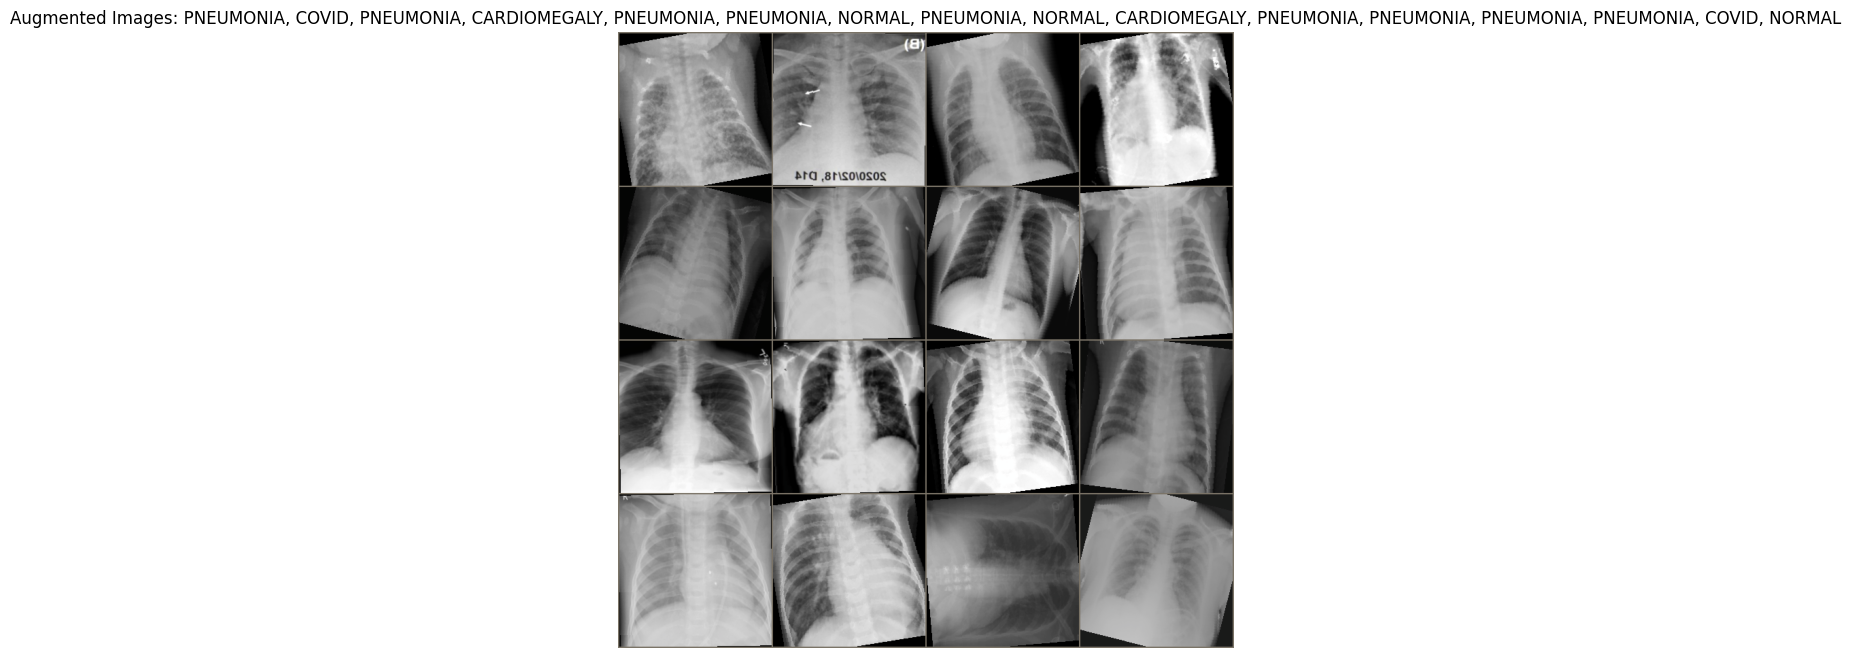

In [6]:
import torchvision

def imshow(img, title=None):
    # Unnormalize the image (reverse the normalization)
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = img.numpy().transpose((1, 2, 0))  # Convert from (C, H, W) to (H, W, C)
    img = (img * std) + mean                # Unnormalize
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')

# Retrieve one batch of images from the training DataLoader
data_iter = iter(train_loader)
images, labels = next(data_iter)

# Create a grid of images using torchvision's utility function
img_grid = torchvision.utils.make_grid(images, nrow=4)

# Convert labels (numerical) to class names
class_names = train_dataset.classes
label_names = [class_names[label] for label in labels]

plt.figure(figsize=(12, 8))
imshow(img_grid, title="Augmented Images: " + ", ".join(label_names))
plt.show()


In [10]:
import torch.nn as nn
import torch

class ShallowCNNModel(nn.Module):
    def __init__(self, num_classes):
        super(ShallowCNNModel, self).__init__()
        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),  # (B, 16, 224, 224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # (B, 16, 112, 112)

            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),  # (B, 32, 112, 112)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # (B, 32, 56, 56)

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # (B, 64, 56, 56)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # (B, 64, 28, 28)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # Flatten the tensor
        x = self.fc_layers(x)
        return x

# Define number of classes (6 diseases)
num_classes = 6

# Initialize the model
model = ShallowCNNModel(num_classes=num_classes)
print(model)


ShallowCNNModel(
  (conv_layers): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=50176, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=6, bias=True)
  )
)


In [12]:
import torch.optim as optim

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training parameters
num_epochs = 60
patience = 4  # Stop if no improvement after 4 epochs
best_val_acc = 0.0
epochs_no_improve = 0

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    # === Training ===
    model.train()
    total, correct, train_loss = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    print(f"Train Loss: {train_loss/total:.4f} | Train Acc: {train_acc:.2f}%")

    # === Validation ===
    model.eval()
    total, correct, val_loss = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    val_acc = 100 * correct / total
    print(f"Val Loss: {val_loss/total:.4f} | Val Acc: {val_acc:.2f}%")

    # === Early Stopping ===
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        print("Validation improved, saving model...")
        torch.save(model.state_dict(), "best_model.pt")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epochs.")

    if epochs_no_improve >= patience:
        print("Early stopping triggered!")
        break



Epoch 1/60
Train Loss: 0.8513 | Train Acc: 68.95%
Val Loss: 0.6925 | Val Acc: 75.33%
Validation improved, saving model...

Epoch 2/60
Train Loss: 0.7516 | Train Acc: 73.09%
Val Loss: 0.6659 | Val Acc: 75.23%
No improvement for 1 epochs.

Epoch 3/60
Train Loss: 0.7139 | Train Acc: 73.60%
Val Loss: 0.6002 | Val Acc: 77.88%
Validation improved, saving model...

Epoch 4/60
Train Loss: 0.6676 | Train Acc: 75.45%
Val Loss: 0.5885 | Val Acc: 78.59%
Validation improved, saving model...

Epoch 5/60
Train Loss: 0.6397 | Train Acc: 76.50%
Val Loss: 0.5255 | Val Acc: 81.09%
Validation improved, saving model...

Epoch 6/60
Train Loss: 0.6127 | Train Acc: 77.96%
Val Loss: 0.5376 | Val Acc: 80.28%
No improvement for 1 epochs.

Epoch 7/60
Train Loss: 0.5901 | Train Acc: 78.40%
Val Loss: 0.5128 | Val Acc: 81.70%
Validation improved, saving model...

Epoch 8/60
Train Loss: 0.5664 | Train Acc: 79.56%
Val Loss: 0.5057 | Val Acc: 81.45%
No improvement for 1 epochs.

Epoch 9/60
Train Loss: 0.5620 | Train A

<ipython-input-16-b19193ea956a>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt"))


Test Loss: 0.3824 | Test Accuracy: 87.39%

Confusion Matrix:
 [[271   5   3   0   0   0]
 [ 10 118  16   1   5   3]
 [  4   5 616  10  49   1]
 [  1   1  36 439   6   0]
 [  6  13  67   1 208   1]
 [  1   0   2   0   1  66]]

Classification Report:
               precision    recall  f1-score   support

CARDIOMEGALY       0.92      0.97      0.95       279
       COVID       0.83      0.77      0.80       153
      NORMAL       0.83      0.90      0.86       685
   PNEUMONIA       0.97      0.91      0.94       483
PNEUMOTHORAX       0.77      0.70      0.74       296
TUBERCULOSIS       0.93      0.94      0.94        70

    accuracy                           0.87      1966
   macro avg       0.88      0.87      0.87      1966
weighted avg       0.87      0.87      0.87      1966



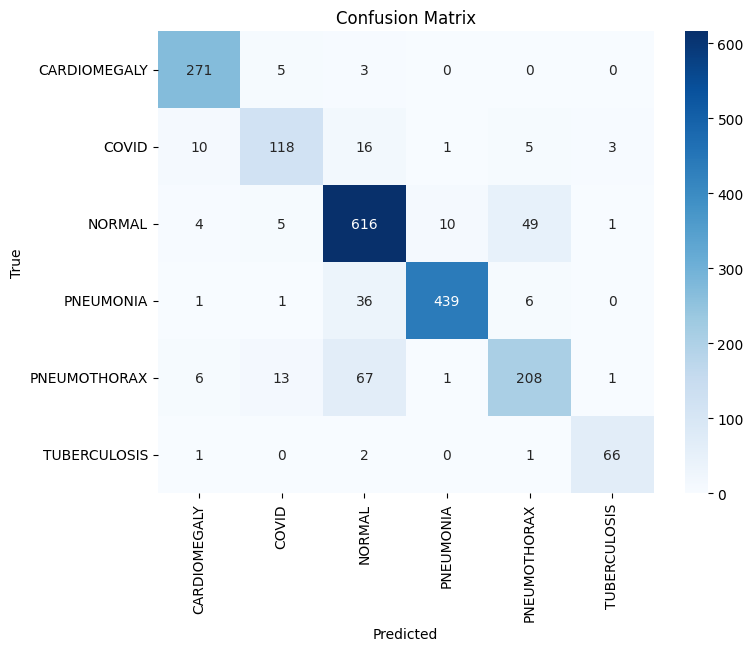

In [16]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Load best saved model
model.load_state_dict(torch.load("best_model.pt"))
model.to(device)
model.eval()

# Initialize accumulators
total, correct, test_loss = 0, 0, 0
all_labels, all_preds = [], []

# Evaluate on test set
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

# Compute overall test performance
test_loss /= total
test_acc = 100 * correct / total
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}%")

# Confusion Matrix & Classification Report
cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(all_labels, all_preds, 
      target_names=test_loader.dataset.classes))

# Visualize Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_loader.dataset.classes, 
            yticklabels=test_loader.dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

